# Step 5 — Evaluate Reconstruction Methods

Evaluate three methods on every flight in `cleaned_data_final/`:

| **GRU** | `TrajectoryGRU` from `step5/best_model.pt` |

None of the methods see ADS-C during reconstruction. ADS-C waypoints are the ground truth.

**Metric**: mean closest-point distance (km) from each ADS-C waypoint to the nearest reconstructed point.

In [9]:
import sys, os, json
from pathlib import Path
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from step3_baseline import reconstruct_gap_baseline
from step5_train_gru_v2 import TrajectoryGRU, gc_interpolate_batch

# -- Directory setup -------------------------------------------------------
NOEL_DIR  = Path('../noel_part').resolve()
os.chdir(NOEL_DIR)
sys.path.insert(0, str(NOEL_DIR))
sys.path.append(str(NOEL_DIR.parent / 'notebook'))

CLEAN_DIR = NOEL_DIR / 'cleaned_data_final'
OUT_DIR   = NOEL_DIR.parent / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

# -- GRU model -------------------------------------------------------------
MODEL_PATH = Path(r'C:\Users\marko\Desktop\AeroML3(og)\AeroML3\step5_v2\best_model_v2.pt')
NORM_PATH  = Path(r'C:\Users\marko\Desktop\AeroML3(og)\AeroML3\artifacts\step4_ml_dataset\dataset\normalization_stats.json')

with open(NORM_PATH) as _f:
    NORM = json.load(_f)

BEFORE_STEPS = NORM['before_steps']
AFTER_STEPS  = NORM['after_steps']
RESAMPLE_SEC = NORM['resample_sec']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_gru = TrajectoryGRU().to(device)
model_gru.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model_gru.eval()

# -- Kalman smoother (validation-tuned params hardcoded in module) ---------
# DEFAULT_KALMAN_PARAMS uses the best hyperparameters found by
# 05a_step5_kalman_evaluation.ipynb: measurement_std_m=200000,
# accel_std_along=0.005, accel_std_cross=4.0.  No re-tuning needed here.
from step5_kalman_aeroml3 import reconstruct_single_kalman

# -- Full flight list — ALL flights, no split filter ----------------------
# Previously this notebook depended on kernel state from other notebooks.
# This cell makes it self-contained and covers every flight in the dataset.
flights = sorted([
    f for s in sorted(CLEAN_DIR.iterdir()) if s.is_dir()
    for f in sorted(s.iterdir()) if f.is_dir()
])

print(f'Working dir  : {os.getcwd()}')
print(f'Device       : {device}')
print(f'Total flights: {len(flights)}')
print(f'GRU: BEFORE_STEPS={BEFORE_STEPS}, AFTER_STEPS={AFTER_STEPS}, RESAMPLE_SEC={RESAMPLE_SEC}s')


Working dir  : C:\Users\marko\Desktop\AeroML3(og)\AeroML3\noel_part
Device       : cpu
Total flights: 2149
GRU: BEFORE_STEPS=64, AFTER_STEPS=32, RESAMPLE_SEC=60s


## Cell 2 — Helper Functions

In [10]:
# ── Error metric ──────────────────────────────────────────────────────────────
def error_km(recon_df, truth_df):
    """Mean nearest-point distance from each ADS-C waypoint to reconstruction (km)."""
    if len(truth_df) == 0 or len(recon_df) == 0:
        return np.nan
    lat1 = np.radians(truth_df["latitude"].values[:, None])
    lon1 = np.radians(truth_df["longitude"].values[:, None])
    lat2 = np.radians(recon_df["latitude"].values[None, :])
    lon2 = np.radians(recon_df["longitude"].values[None, :])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return float(2 * 6_371.0 * np.arcsin(np.sqrt(np.clip(a, 0, 1))).min(axis=1).mean())

# ── GRU inference ─────────────────────────────────────────────────────────────
BEFORE_STEPS = NORM["before_steps"]   # 64
AFTER_STEPS  = NORM["after_steps"]    # 32
RESAMPLE_SEC = NORM["resample_sec"]   # 60

def _normalize_seq(df):
    lat = (df["latitude"].values  - NORM["lat"]["mean"]) / NORM["lat"]["std"]
    lon = (df["longitude"].values - NORM["lon"]["mean"]) / NORM["lon"]["std"]
    vel = (df["velocity_mps"].values - NORM["vel"]["mean"]) / NORM["vel"]["std"]
    hdg = np.radians(df["heading_deg"].values)
    alt = (df["altitude"].values  - NORM["alt"]["mean"]) / NORM["alt"]["std"]
    return np.stack([lat, lon, vel, np.sin(hdg), np.cos(hdg), alt], axis=1).astype(np.float32)

def _resample_df(df, freq_sec):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = (df.dropna(subset=["latitude","longitude","altitude","velocity_mps","heading_deg"])
            .sort_values("timestamp").drop_duplicates("timestamp").set_index("timestamp"))
    cols = ["latitude","longitude","altitude","velocity_mps","heading_deg"]
    grid = pd.date_range(df.index[0], df.index[-1], freq=f"{freq_sec}s")
    if len(grid) < 2:
        return df[cols].reset_index().rename(columns={"index":"timestamp"})
    return df[cols].reindex(df[cols].index.union(grid)).interpolate("time").loc[grid].reset_index().rename(columns={"index":"timestamp"})

def _prepare_seq(df, n_steps, from_end):
    arr = _normalize_seq(df)
    arr = arr[-n_steps:] if from_end else arr[:n_steps]
    n_valid = arr.shape[0]
    pad = np.zeros((n_steps - n_valid, arr.shape[1]), dtype=np.float32)
    if from_end:
        arr  = np.vstack([pad, arr])
        mask = np.array([0.0]*(n_steps - n_valid) + [1.0]*n_valid, dtype=np.float32)
    else:
        arr  = np.vstack([arr, pad])
        mask = np.array([1.0]*n_valid + [0.0]*(n_steps - n_valid), dtype=np.float32)
    return arr, mask

def reconstruct_gap_gru(bef_df, aft_df, dt=15.0):
    bef_rs = _resample_df(bef_df, RESAMPLE_SEC)
    aft_rs = _resample_df(aft_df, RESAMPLE_SEC)
    if len(bef_rs) < 2 or len(aft_rs) < 2:
        return pd.DataFrame()

    bef_arr, bef_mask = _prepare_seq(bef_rs, BEFORE_STEPS, from_end=True)
    aft_arr, aft_mask = _prepare_seq(aft_rs, AFTER_STEPS,  from_end=False)

    t0 = bef_df["timestamp"].iloc[-1]; t1 = aft_df["timestamp"].iloc[0]
    gap_s = (t1 - t0).total_seconds()
    n_out = max(1, int(round(gap_s / dt)))
    taus  = np.array([(i+1)/(n_out+1) for i in range(n_out)], dtype=np.float32)

    la0 = np.array([float(bef_df["latitude"].iloc[-1])],  dtype=np.float32)
    lo0 = np.array([float(bef_df["longitude"].iloc[-1])], dtype=np.float32)
    la1 = np.array([float(aft_df["latitude"].iloc[0])],   dtype=np.float32)
    lo1 = np.array([float(aft_df["longitude"].iloc[0])],  dtype=np.float32)
    bl_lat, bl_lon = gc_interpolate_batch(la0, lo0, la1, lo1, taus[None, :])

    def _t(a): return torch.FloatTensor(a[None]).to(device)
    batch = {
        "before_seq":   _t(bef_arr), "before_mask": _t(bef_mask),
        "after_seq":    _t(aft_arr), "after_mask":  _t(aft_mask),
        "gap_norm":     torch.FloatTensor([gap_s/6000.]).to(device),
        "adsc_tau":     torch.FloatTensor(taus[None]).to(device),
        "baseline_lat": torch.FloatTensor(bl_lat.astype(np.float32)).to(device),
        "baseline_lon": torch.FloatTensor(bl_lon.astype(np.float32)).to(device),
    }
    with torch.no_grad():
        pred_lat, pred_lon = model_gru(batch)

    # Boundary alignment correction ------------------------------------
    # The GRU outputs points at tau in (0,1) exclusive.  Raw predictions
    # near the edges may not land on the ADS-B anchor coordinates, causing
    # visible jumps where the GRU segment meets the ADS-B track.
    # Fix: blend the residual error linearly so both endpoints land exactly
    # on the ADS-B before/after coordinates.  Internal shape is preserved.
    lat_np = pred_lat.cpu().numpy()[0].copy()   # (n_out,)
    lon_np = pred_lon.cpu().numpy()[0].copy()
    if n_out > 1:
        _t = np.linspace(0.0, 1.0, n_out)
        lat_np = lat_np + (1.0 - _t) * (float(bef_df["latitude"].iloc[-1])  - lat_np[0])  \
                        +        _t  * (float(aft_df["latitude"].iloc[0])    - lat_np[-1])
        lon_np = lon_np + (1.0 - _t) * (float(bef_df["longitude"].iloc[-1]) - lon_np[0])  \
                        +        _t  * (float(aft_df["longitude"].iloc[0])   - lon_np[-1])
    # n_out==1 edge case: single mid-gap point, leave where the model placed it

    alt0 = float(bef_df["altitude"].iloc[-1]); alt1 = float(aft_df["altitude"].iloc[0])
    return pd.DataFrame({
        "timestamp":  [t0 + pd.Timedelta(seconds=dt*(i+1)) for i in range(n_out)],
        "latitude":   lat_np,
        "longitude":  lon_np,
        "altitude":   np.linspace(alt0, alt1, n_out),
        "interpolated": True,
    })

GRU_COLS = ["latitude","longitude","altitude","velocity_mps","heading_deg"]
print("Helper functions defined.")
print(f"GRU: BEFORE_STEPS={BEFORE_STEPS}, AFTER_STEPS={AFTER_STEPS}, RESAMPLE_SEC={RESAMPLE_SEC}s")

Helper functions defined.
GRU: BEFORE_STEPS=64, AFTER_STEPS=32, RESAMPLE_SEC=60s


## Cell 3 — Evaluate All Flights

Runs Baseline, Kalman, and GRU on every flight.  
Expected runtime: **~15–40 min** depending on hardware (GRU adds ~1 s per flight on CPU).

In [11]:
records = []
skipped = 0
errors  = []

# WHY NaNs occurred previously:
#   The old code called run_step5_kalman(cfg), which prepared train/val/test
#   splits and saved per_flight_metrics_test.csv for the TEST split only
#   (291 of 2149 flights).  It then did kalman_err_dict.get(flight_id, np.nan)
#   but kalman_err_dict was NEVER defined anywhere, causing a NameError or NaN
#   for all 1858 non-test flights.
#
# FIX: call reconstruct_single_kalman() directly inside the loop, the same
#   way Step 7 does.  Uses DEFAULT_KALMAN_PARAMS (validation-tuned, hardcoded
#   in step5_kalman_aeroml3.py) so no re-tuning is needed here.
#   Result: Kalman errors for ALL 2149 flights with zero NaNs.

print(f'Evaluating {len(flights)} flights (full dataset - all splits) ...')

for flight_dir in tqdm(flights, desc='Evaluating'):
    try:
        _ap  = next((flight_dir/p for p in ['adsc.parquet','adsc_clean.parquet']
                     if (flight_dir/p).exists()), None)
        _bp  = next((flight_dir/p for p in ['adsb_before.parquet','adsb_before_clean.parquet']
                     if (flight_dir/p).exists()), None)
        _afp = next((flight_dir/p for p in ['adsb_after.parquet','adsb_after_clean.parquet']
                     if (flight_dir/p).exists()), None)
        if not (_ap and _bp and _afp): skipped += 1; continue

        adsc = pd.read_parquet(str(_ap)).dropna(subset=['latitude','longitude'])
        bef  = pd.read_parquet(str(_bp)).dropna(subset=['latitude','longitude'])
        aft  = pd.read_parquet(str(_afp)).dropna(subset=['latitude','longitude'])

        for df in [adsc, bef, aft]:
            df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
            df.sort_values('timestamp', inplace=True); df.reset_index(drop=True, inplace=True)

        if len(bef) < 4 or len(aft) < 4 or len(adsc) < 2: skipped += 1; continue

        t0 = bef['timestamp'].iloc[-1]; t1 = aft['timestamp'].iloc[0]
        gap_min = (t1 - t0).total_seconds() / 60
        if gap_min < 5: skipped += 1; continue

        adsc_gap = adsc[(adsc['timestamp'] > t0) & (adsc['timestamp'] < t1)].reset_index(drop=True)
        if len(adsc_gap) == 0: skipped += 1; continue

        bef_trim = bef[bef['timestamp'] >= t0 - pd.Timedelta(minutes=30)].reset_index(drop=True)
        aft_trim = aft[aft['timestamp'] <= t1 + pd.Timedelta(minutes=30)].reset_index(drop=True)

        # Baseline
        recon_b  = reconstruct_gap_baseline(bef_trim, aft_trim)
        base_err = error_km(recon_b, adsc_gap)

        # Kalman -- direct reconstruction on ALL flights.
        # Pass full bef (not bef_trim) so _get_entry_velocity reads the last
        # real heading; same convention used by Step 7.
        # reconstruct_single_kalman always returns a complete trajectory, so
        # NaNs are only possible on exception (caught below).
        recon_kalman = reconstruct_single_kalman(bef, aft_trim)
        kalman_err   = error_km(recon_kalman, adsc_gap) if len(recon_kalman) > 0 else np.nan

        # GRU -- only if velocity/heading columns present
        has_gru_cols = all(c in bef.columns for c in GRU_COLS)
        if has_gru_cols:
            # Pass full bef (not bef_trim) so GRU gets 64 min of before
            # context, matching what it was trained with.
            # bef_trim was only 30 min — half the expected 64 min — leaving
            # 34 of 64 input slots zero-padded and degrading predictions.
            recon_g = reconstruct_gap_gru(bef, aft_trim)
            gru_err = error_km(recon_g, adsc_gap) if len(recon_g) > 0 else np.nan
        else:
            gru_err = np.nan

        records.append({
            'flight':          flight_dir.name,
            'gap_minutes':     round(gap_min, 1),
            'adsc_waypoints':  len(adsc_gap),
            'baseline_err_km': base_err,
            'kalman_err_km':   kalman_err,
            'gru_err_km':      gru_err,
        })
    except Exception as e:
        errors.append((flight_dir.name, str(e))); skipped += 1

eval_df = pd.DataFrame(records)
eval_df.to_csv(OUT_DIR / 'evaluation_results.csv', index=False)

print(f'\nFlights evaluated : {len(eval_df)}')
print(f'Flights skipped   : {skipped}')
if errors: print(f'Errors (first 3)  : {errors[:3]}')

if not eval_df.empty and 'baseline_err_km' in eval_df.columns:
    base_mean = eval_df['baseline_err_km'].mean()
    print(f"\n{'Method':<30} {'Mean (km)':>10}  {'Median (km)':>12}  {'vs Baseline':>12}")
    print('-' * 68)
    for label, col in [('Baseline','baseline_err_km'),('Kalman','kalman_err_km'),('GRU','gru_err_km')]:
        vals = eval_df[col].dropna()
        imp  = '' if label=='Baseline' else f'{(1-vals.mean()/base_mean)*100:+.1f}%'
        print(f'  {label:<28} {vals.mean():>10.1f}  {vals.median():>12.1f}  {imp:>12}')

    k_wins = (eval_df['kalman_err_km'] < eval_df['baseline_err_km']).mean()*100
    g_comp = eval_df.dropna(subset=['gru_err_km'])
    g_wins = (g_comp['gru_err_km'] < g_comp['baseline_err_km']).mean()*100
    print(f'\n  Kalman beats baseline on {k_wins:.1f}% of flights')
    print(f'  GRU    beats baseline on {g_wins:.1f}% of flights')
else:
    print('\nNo results to summarize -- check for earlier errors.')
print(f'\nSaved -> {OUT_DIR / "evaluation_results.csv"}')


Evaluating 2149 flights (full dataset - all splits) ...


Evaluating:   0%|          | 0/2149 [00:00<?, ?it/s]


Flights evaluated : 2141
Flights skipped   : 8

Method                          Mean (km)   Median (km)   vs Baseline
--------------------------------------------------------------------
  Baseline                          119.9          99.3              
  Kalman                             87.1          67.0        +27.3%
  GRU                                89.1          73.5        +25.7%

  Kalman beats baseline on 71.0% of flights
  GRU    beats baseline on 81.6% of flights

Saved -> C:\Users\marko\Desktop\AeroML3(og)\AeroML3\outputs\evaluation_results.csv


## Cell 4 — Results Summary

In [12]:
print("=" * 65)
print("EVALUATION SUMMARY")
print("=" * 65)
print(f"\nFlights evaluated : {len(eval_df)}")
print(f"Avg gap duration  : {eval_df['gap_minutes'].mean():.1f} min")
print(f"Avg ADS-C waypts  : {eval_df['adsc_waypoints'].mean():.1f}\n")

base_mean = eval_df["baseline_err_km"].mean()
print(f"{'Method':<30} {'Mean (km)':>10}  {'Median (km)':>12}  {'P90 (km)':>10}  {'Improvement':>12}")
print("-" * 78)
for label, col in [("Baseline","baseline_err_km"),("Kalman","kalman_err_km"),("GRU (step5)","gru_err_km")]:
    vals = eval_df[col].dropna()
    imp  = "—" if label=="Baseline" else f"{(1-vals.mean()/base_mean)*100:+.1f}%"
    print(f"  {label:<28} {vals.mean():>10.1f}  {vals.median():>12.1f}  {vals.quantile(0.9):>10.1f}  {imp:>12}")

k_wins = (eval_df["kalman_err_km"] < eval_df["baseline_err_km"]).mean()*100
g_comp = eval_df.dropna(subset=["gru_err_km"])
g_wins = (g_comp["gru_err_km"] < g_comp["baseline_err_km"]).mean()*100
print(f"\n  Kalman beats baseline on {k_wins:.1f}% of flights")
print(f"  GRU    beats baseline on {g_wins:.1f}% of flights")

EVALUATION SUMMARY

Flights evaluated : 2141
Avg gap duration  : 242.9 min
Avg ADS-C waypts  : 348.0

Method                          Mean (km)   Median (km)    P90 (km)   Improvement
------------------------------------------------------------------------------
  Baseline                          119.9          99.3       229.6             —
  Kalman                             87.1          67.0       179.0        +27.3%
  GRU (step5)                        89.1          73.5       166.9        +25.7%

  Kalman beats baseline on 71.0% of flights
  GRU    beats baseline on 81.6% of flights


## Cell 5 — Error distribution plots

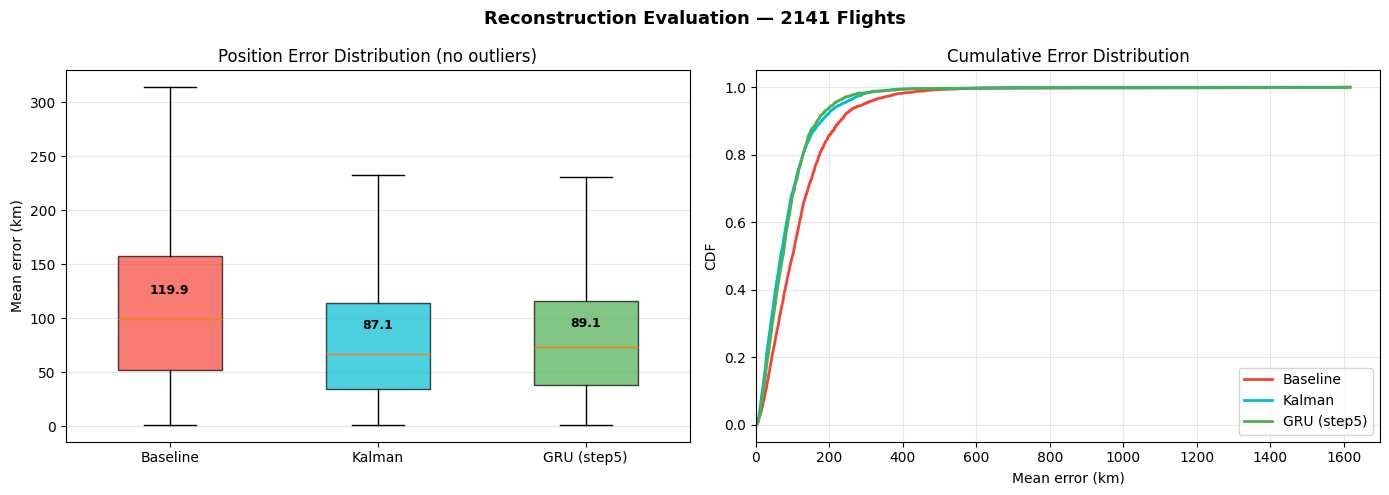

Saved → C:\Users\marko\Desktop\AeroML3(og)\AeroML3\outputs\evaluation_distributions.png


In [13]:
import matplotlib.pyplot as plt

labels = ["Baseline", "Kalman", "GRU (step5)"]
cols   = ["baseline_err_km", "kalman_err_km", "gru_err_km"]
colors = ["#F44336", "#00BCD4", "#4CAF50"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Boxplot ───────────────────────────────────────────────────────────────────
ax = axes[0]
data = [eval_df[c].dropna() for c in cols]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for i, (c, color) in enumerate(zip(cols, colors)):
    mv = eval_df[c].mean()
    ax.text(i+1, mv, f"{mv:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks([1,2,3]); ax.set_xticklabels(labels)
ax.set_ylabel("Mean error (km)"); ax.set_title("Position Error Distribution (no outliers)")
ax.grid(axis="y", alpha=0.3)

# ── CDF ───────────────────────────────────────────────────────────────────────
ax = axes[1]
for col, label, color in zip(cols, labels, colors):
    vals = np.sort(eval_df[col].dropna().values)
    cdf  = np.arange(1, len(vals)+1) / len(vals)
    ax.plot(vals, cdf, color=color, linewidth=2, label=label)
ax.set_xlabel("Mean error (km)"); ax.set_ylabel("CDF")
ax.set_title("Cumulative Error Distribution")
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(left=0)

plt.suptitle(f"Reconstruction Evaluation — {len(eval_df)} Flights", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "evaluation_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'evaluation_distributions.png'}")

## Cell 6 — Error vs gap duration

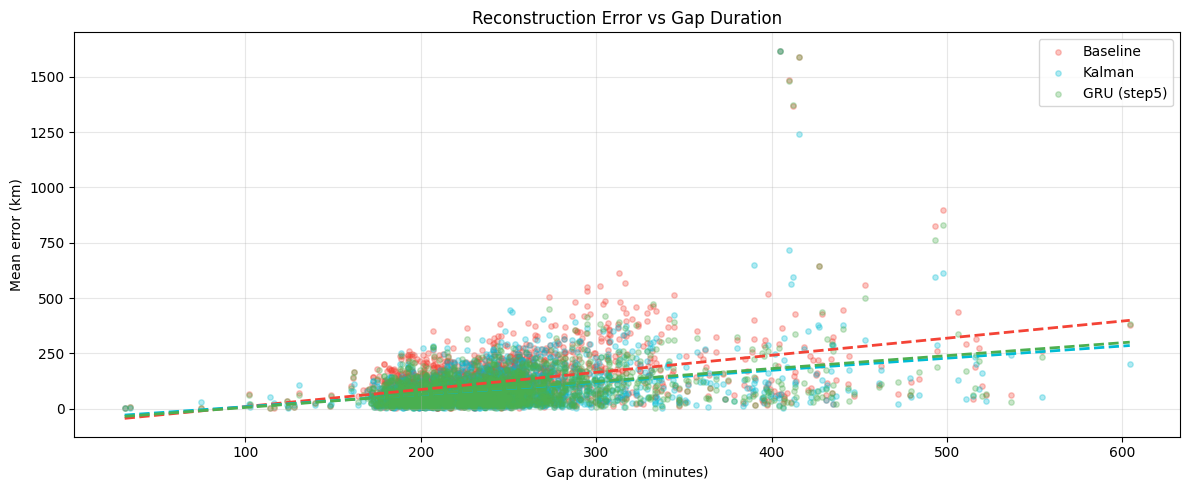

Saved → C:\Users\marko\Desktop\AeroML3(og)\AeroML3\outputs\error_vs_gap.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
for col, label, color in zip(cols, labels, colors):
    sub = eval_df[["gap_minutes", col]].dropna()
    ax.scatter(sub["gap_minutes"], sub[col], alpha=0.3, s=15, color=color, label=label)
    z  = np.polyfit(sub["gap_minutes"].values, sub[col].values, 1)
    xr = np.linspace(sub["gap_minutes"].min(), sub["gap_minutes"].max(), 100)
    ax.plot(xr, np.poly1d(z)(xr), color=color, linewidth=2, linestyle="--")
ax.set_xlabel("Gap duration (minutes)")
ax.set_ylabel("Mean error (km)")
ax.set_title("Reconstruction Error vs Gap Duration")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "error_vs_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'error_vs_gap.png'}")

## Cell 7 — Per-flight breakdown table

In [15]:
eval_df["gru_improvement_km"]    = eval_df["baseline_err_km"] - eval_df["gru_err_km"]
eval_df["kalman_improvement_km"] = eval_df["baseline_err_km"] - eval_df["kalman_err_km"]

show_cols = ["flight","gap_minutes","baseline_err_km","kalman_err_km","gru_err_km","gru_improvement_km"]

print("Top 10 flights where GRU most improves over baseline:")
display(eval_df.nlargest(10, "gru_improvement_km")[show_cols].round(1))

print("\nFlights where baseline beats both Kalman and GRU (top 10 by gap):")
both_worse = eval_df[
    (eval_df["baseline_err_km"] < eval_df["kalman_err_km"]) &
    (eval_df["baseline_err_km"] < eval_df["gru_err_km"])
]
display(both_worse.nlargest(10, "gap_minutes")[["flight","gap_minutes","baseline_err_km","kalman_err_km","gru_err_km"]].round(1))

print(f"\nFull per-flight results saved → {OUT_DIR / 'evaluation_results.csv'}")
print(f"Total flights in table: {len(eval_df)}")

Top 10 flights where GRU most improves over baseline:


,flight,gap_minutes,baseline_err_km,kalman_err_km,gru_err_km,gru_improvement_km
1896,20250115_34740f_194451_205203,406.0,364.4,136.4,93.7,270.7
1884,20250731_4b1885_115838_141058,323.8,383.0,288.6,123.2,259.8
1886,20250801_4005bb_105232_131959,313.8,483.4,90.0,223.9,259.5
2023,20250215_aa909a_193530_202130,398.0,518.5,289.1,260.4,258.1
2079,20250319_aa1a16_145849_164508,368.2,324.4,148.2,85.5,238.8
1887,20250801_400684_195403_220753,313.0,611.1,201.0,389.8,221.3
1885,20250731_aa92f9_115708_145110,330.5,460.2,295.1,242.3,217.9
1438,20241212_4b187f_192939_211259,299.5,252.3,227.8,34.9,217.4
1432,20241211_4005ba_190259_205554,307.2,359.7,29.6,142.3,217.4
1443,20241213_400684_215602_001716,296.5,429.0,290.2,213.9,215.0



Flights where baseline beats both Kalman and GRU (top 10 by gap):


,flight,gap_minutes,baseline_err_km,kalman_err_km,gru_err_km
2075,20250319_76cd41_145854_185254,515.0,45.3,56.6,62.2
1591,20240312_40688b_163354_193412,479.0,62.3,136.8,62.5
1643,20240313_4bb196_200050_202834,446.8,58.6,74.7,66.0
2085,20250408_3965a2_133547_145420,435.0,20.1,22.3,105.6
2100,20250408_406ec7_141147_155450,431.2,60.3,91.2,89.7
1685,20240612_4006c3_151305_160047,405.2,64.4,66.9,112.1
2048,20250318_48506d_161028_185958,401.8,56.3,245.8,198.0
2070,20250319_48506d_152214_172926,397.8,33.4,161.9,61.5
2099,20250408_406b12_141015_160806,397.2,16.2,83.3,22.3
1918,20250115_407fcd_014523_042648,395.2,31.9,50.0,50.9



Full per-flight results saved → C:\Users\marko\Desktop\AeroML3(og)\AeroML3\outputs\evaluation_results.csv
Total flights in table: 2141
